In [1]:
import tskit
import msprime
from Bio import Phylo
from io import StringIO

In [2]:
# species tree of all annual taxa (branch length in MYr)
spTree = "((((((Taxa1:7.8,Taxa2:7.8):1.9,((Taxa3:7.8,((Taxa4:0.4,Taxa5:0.4):0.3,Taxa6:0.7):7.1):0.2,(Taxa7:0.1,Taxa8:0.1):7.9):1.7):0.7,(Taxa9:0.3,Taxa10:0.3):10.1):0.6,Taxa11:11):0.3,Taxa12:11.3):1.6,((Taxa13:1.2,Taxa14:1.2):0.1,((Taxa15:1.1,Taxa16:1.1):0.1,Taxa17:1.2):0.1):11.6);"

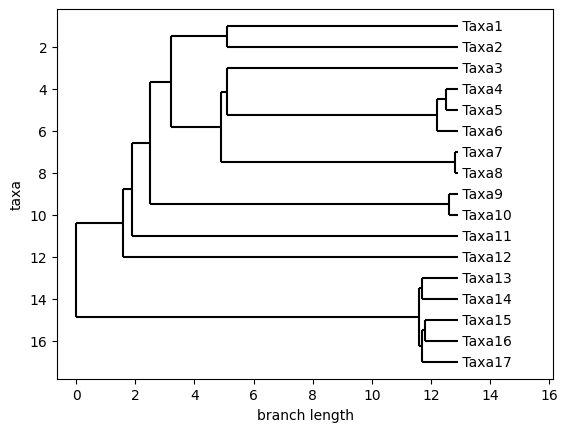

In [3]:
spTree_phylo=Phylo.read(StringIO(spTree),"newick")
Phylo.draw(spTree_phylo)

In [4]:
# msprime based on the species tree demography
# recombination_rate of 0.5 makes each tree independent (different genes)
# sequence_length then specify number of trees
demography = msprime.Demography.from_species_tree(
    spTree,
    time_units="myr",
    initial_size=10**4,
    generation_time=1)
ts = msprime.sim_ancestry({"Taxa1": 1, "Taxa2": 1,"Taxa3":1,"Taxa4":1,"Taxa5":1,"Taxa6":1,
                          "Taxa7":1,"Taxa8":1,"Taxa9":1,"Taxa10":1,"Taxa11":1,"Taxa12":1,
                          "Taxa13":1,"Taxa14":1,"Taxa15":1,"Taxa16":1,"Taxa17":1}, demography=demography,ploidy=1,
                          random_seed=123,sequence_length=1000,recombination_rate=1/2)
ts


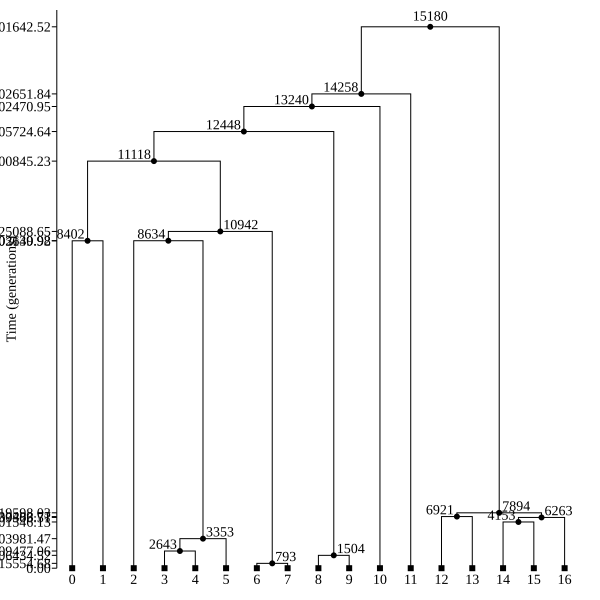

In [5]:
t1=ts.first()
t1.draw_svg(y_axis=True,size=[600,600])

In [20]:
#drop mutations (rate can be varied)
ts_mutated = msprime.sim_mutations(ts, rate=2.5e-8)
ts_mutated

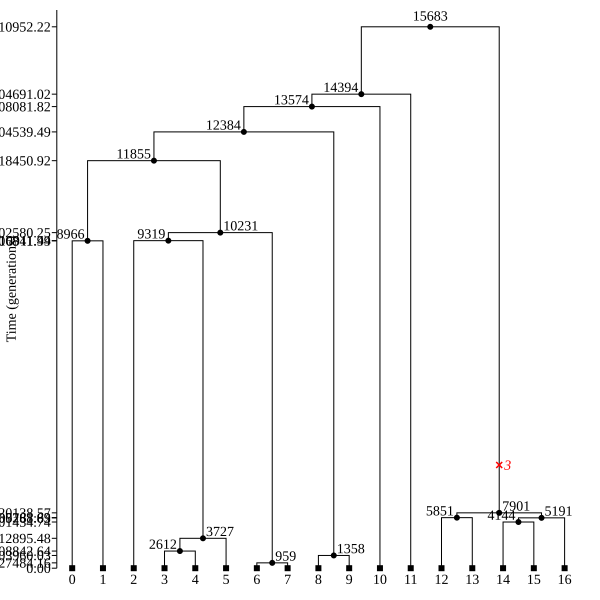

In [27]:
ts_mutated.aslist()[1].draw_svg(y_axis=True,size=[600,600])

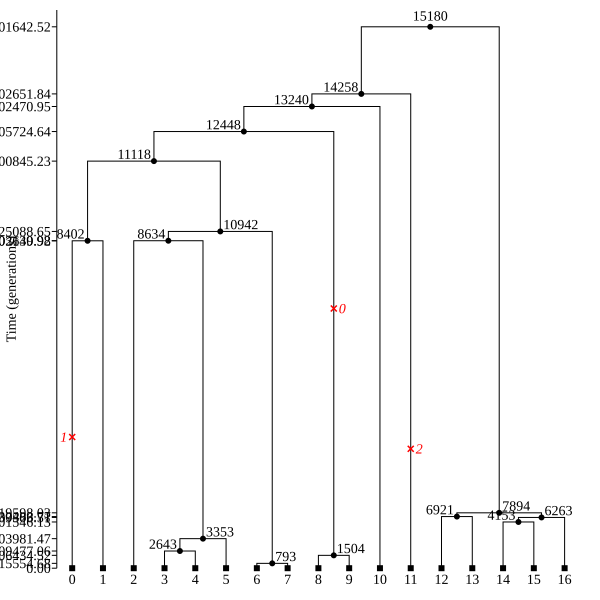

In [28]:
ts_mutated.aslist()[0].draw_svg(y_axis=True,size=[600,600])

In [23]:
len(ts_mutated.genotype_matrix())

905

In [24]:
# anything non-zero is considered as gene-loss
ts_mutated.genotype_matrix()[2]

array([1, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0], dtype=int32)

In [26]:
import numpy as np
a=np.array(ts_mutated.genotype_matrix())
np.savetxt("/workdir/sh2246/p_phyloGWAS/output/tskit_mutatedGenotypeMatrix_1000Tree_mu2.5e-8.txt", a, fmt='%i')